Correlation Values
Original - Karaoke :  803.4512
Original - Different :  268.5732
Different - Karaoke :  133.83295


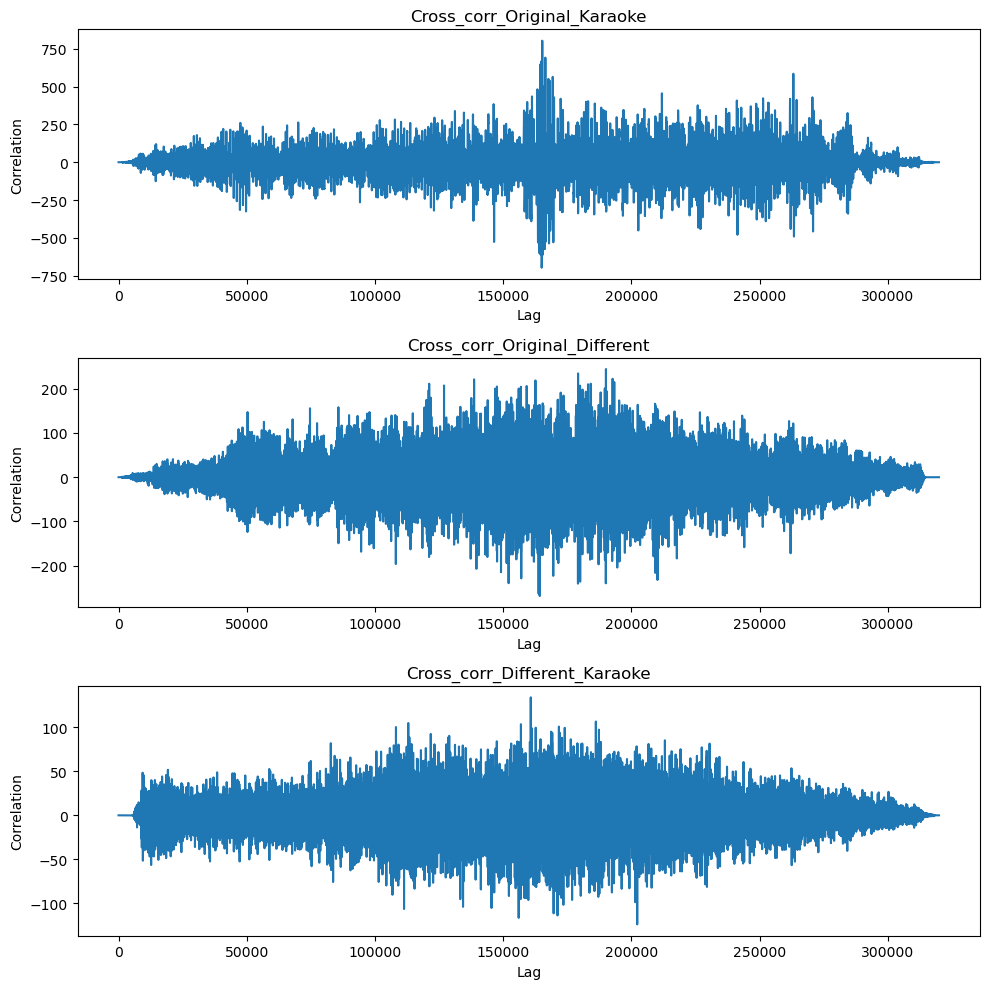

In [1]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt

def cross_correlation(signal1, signal2):
# cross-correlation
  cross_corr = np.correlate(signal1, signal2, mode='full')
  return cross_corr

original = AudioSegment.from_mp3("audio1.mp3")
different = AudioSegment.from_mp3("audio2.mp3")
karaoke = AudioSegment.from_mp3("audio1_karaoke.mp3")

original = original[:5000]
different = different[:5000]
karaoke = karaoke[:5000]

original = original.set_channels(1)
different = different.set_channels(1)
karaoke = karaoke.set_channels(1)

samples_original = np.array(original.get_array_of_samples()).astype(np.float32)
samples_different = np.array(different.get_array_of_samples()).astype(np.float32)
samples_karaoke = np.array(karaoke.get_array_of_samples()).astype(np.float32)

original_norm = samples_original / np.max(np.abs(samples_original))
different_norm = samples_different / np.max(np.abs(samples_different))
karaoke_norm = samples_karaoke / np.max(np.abs(samples_karaoke))

min_length = min(len(original_norm),len(different_norm),len(karaoke_norm))
original_norm = original_norm[:min_length]
different_norm = different_norm[:min_length]
karaoke_norm = karaoke_norm[:min_length]

original_karaoke = cross_correlation(original_norm,karaoke_norm)
original_different = cross_correlation(original_norm,different_norm)
different_karaoke = cross_correlation(different_norm,karaoke_norm)

print("Correlation Values")
print("Original - Karaoke : ",np.max(np.abs(original_karaoke)))
print("Original - Different : ",np.max(np.abs(original_different)))
print("Different - Karaoke : ",np.max(np.abs(different_karaoke)))

plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
plt.plot(original_karaoke)
plt.title('Cross_corr_Original_Karaoke')
plt.xlabel('Lag')
plt.ylabel('Correlation')

plt.subplot(3,1,2)
plt.plot(original_different)
plt.title('Cross_corr_Original_Different')
plt.xlabel('Lag')
plt.ylabel('Correlation')

plt.subplot(3,1,3)
plt.plot(different_karaoke)
plt.title('Cross_corr_Different_Karaoke')
plt.xlabel('Lag')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()
